# Handle Outliers

Identify and address outliers in the dat,asa they can negatively impact model performance

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("dataset.csv")
print("Original coloumn headers:")
print(list(df.columns))

Original coloumn headers:
['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type', 'end_treatment_date', 'survived']


In [34]:
numerical_cols_for_outliers = ['age', 'bmi', 'cholesterol_level']

for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_value = df[col].median()

    df[col] = df[col].apply(lambda x: median_value if x < lower_bound or x > upper_bound else x)

print("Outliers handled in the following columns:")
print(numerical_cols_for_outliers)

Outliers handled in the following columns:
['age', 'bmi', 'cholesterol_level']


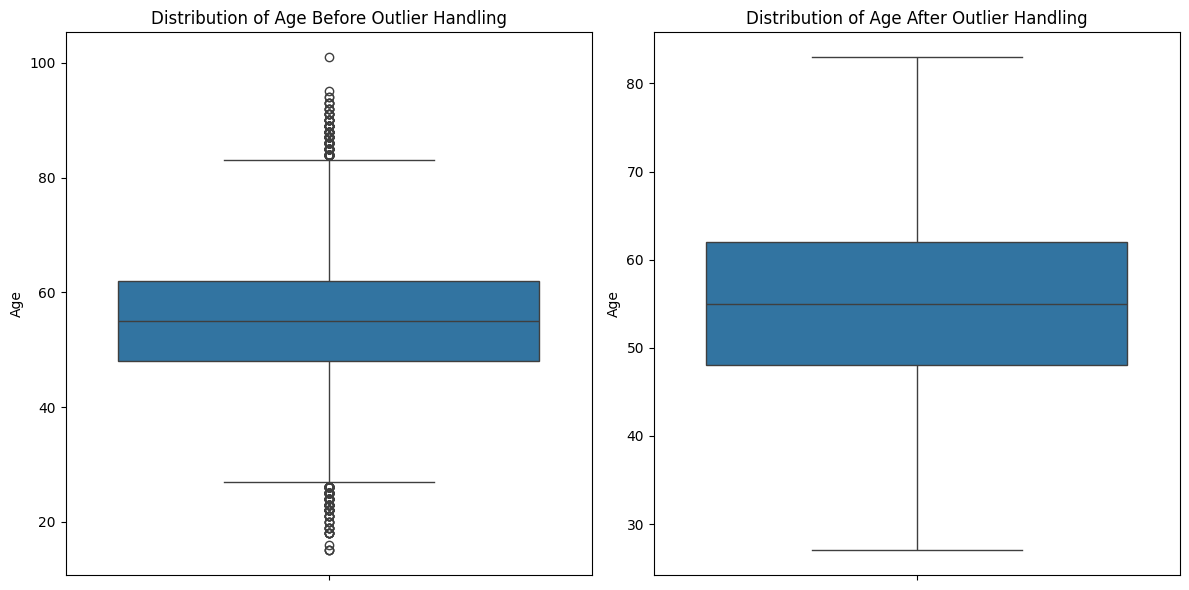


Number of outliers before handling:
  age: 435 outliers
  bmi: 0 outliers
  cholesterol_level: 0 outliers


In [37]:
# Define df_original_smoking by reading the CSV
df_original_smoking = pd.read_csv("dataset.csv")


plt.figure(figsize=(12, 6))

# Boxplot before outlier handling
plt.subplot(1, 2, 1)
sns.boxplot(y=df_original_smoking['age'])
plt.title('Distribution of Age Before Outlier Handling')
plt.ylabel('Age')

# Boxplot after outlier handling
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Distribution of Age After Outlier Handling')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

# Calculate and print the number of outliers before handling
numerical_cols_for_outliers = ['age', 'bmi', 'cholesterol_level']

print("\nNumber of outliers before handling:")
for col in numerical_cols_for_outliers:
    Q1 = df_original_smoking[col].quantile(0.25)
    Q3 = df_original_smoking[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify and count outliers in the original data
    outliers_before = df_original_smoking[(df_original_smoking[col] < lower_bound) | (df_original_smoking[col] > upper_bound)].shape[0]

    print(f"  {col}: {outliers_before} outliers")